# Titanic Survival Prediction

Predicting passenger survival using Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report)

sns.set_style('whitegrid')
%matplotlib inline


In [2]:
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [4]:
data = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
           'fare', 'embarked']].copy()

data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
data['family_size'] = data['sibsp'] + data['parch'] + 1

data.isnull().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
family_size    0
dtype: int64

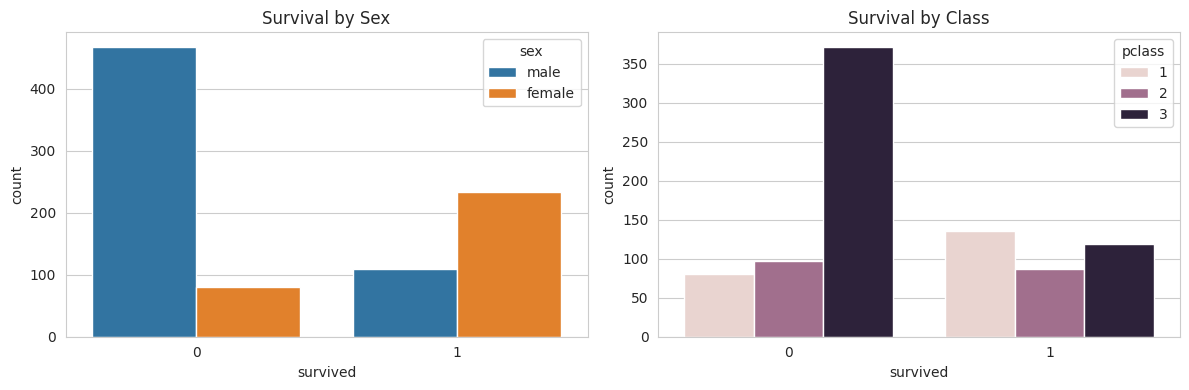

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=data, x='survived', hue='sex', ax=axes[0])
sns.countplot(data=data, x='survived', hue='pclass', ax=axes[1])
axes[0].set_title('Survival by Sex')
axes[1].set_title('Survival by Class')
plt.tight_layout()
plt.savefig('titanic_survival_breakdown.png', bbox_inches='tight', dpi=120)
plt.show()


In [6]:
data_encoded = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)
data_encoded.head()


,survived,pclass,age,sibsp,parch,fare,family_size,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,2,True,False,True
1,1,1,38.0,1,0,71.2833,2,False,False,False
2,1,3,26.0,0,0,7.9250,1,False,False,True
3,1,1,35.0,1,0,53.1000,2,False,False,True
4,0,3,35.0,0,0,8.0500,1,True,False,True


In [7]:
X = data_encoded.drop(columns='survived')
y = data_encoded['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


In [8]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))


Accuracy:  0.804
Precision: 0.793
Recall:    0.667

                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



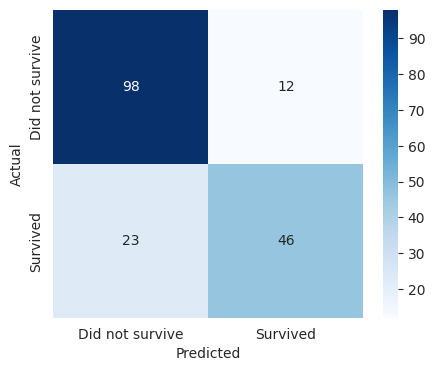

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('titanic_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()
